In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [5]:
im = cv.imread("../assets/market_tiles/raw/background_no_cell.png")

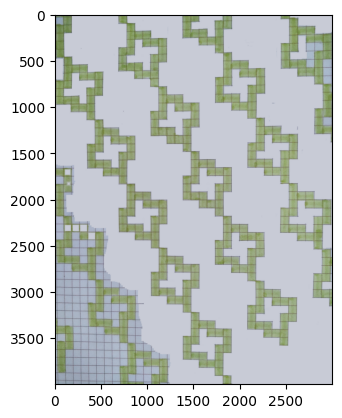

In [6]:
plt.imshow(im)

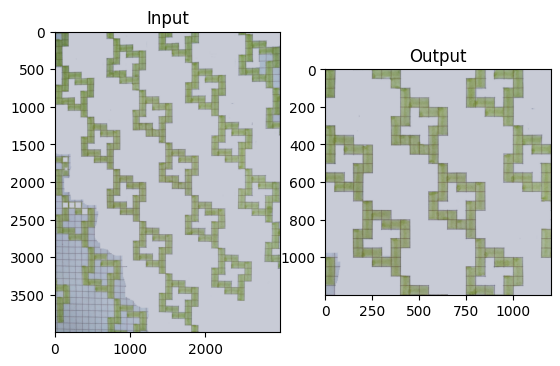

In [7]:
pts1 = np.float32([[598,790],[2351,765],[607,2529],[2345,2537]])
pts2 = np.float32([[100,100],[1100,100],[100,1100],[1100,1100]])
M = cv.getPerspectiveTransform(pts1,pts2)
img = im
dst = cv.warpPerspective(img,M,(1200,1200))
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

In [8]:
D = dst.copy().astype(int)
L = 100
for i in range(L):
    t = i/(L-1)
    #print(i, (1-t)/2, (1-(1-t)/2))
    D[100+i] = D[1100+i] * (1-t)/2 + D[100+i] * (t+1)/2
    D[1100-i] = D[100-i] * (1-t)/2 + D[1099-i] * (t+1)/2
for i in range(L):
    t = i/(L-1)
    #print(i, (1-t)/2, (1-(1-t)/2))
    D[:,100+i] = D[:,1100+i] * (1-t)/2 + D[:,100+i] * (t+1)/2
    D[:,1100-i] = D[:,100-i] * (1-t)/2 + D[:,1099-i] * (t+1)/2

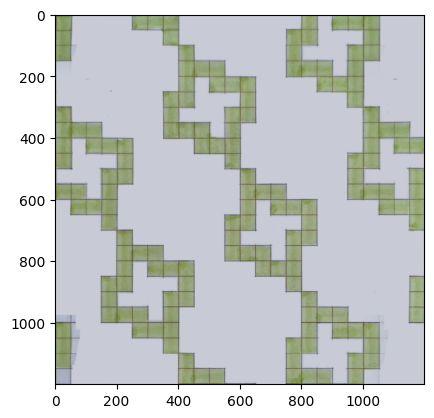

In [9]:
plt.imshow(D)

In [10]:
R = D[100:1100, 100:1100].astype("uint8")

In [9]:
cv.imwrite("test.png")

error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'imwrite'
> Overload resolution failed:
>  - imwrite() missing required argument 'img' (pos 2)
>  - imwrite() missing required argument 'img' (pos 2)


In [11]:
tiled = np.tile(R, (3, 3, 1))

In [13]:

resized = cv.resize(tiled, (600, 600))#, interpolation=cv.INTER_AREA)

In [14]:
cv.imwrite("test2.png", resized[200:400, 200:400])

True

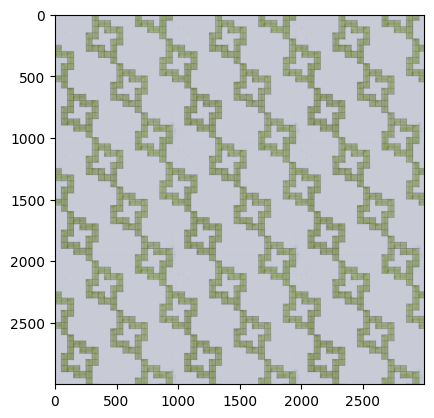

In [12]:
plt.imshow(tiled)